# Heart rate specific template

This is a template for analysing, cleaning, and extracting features for heart rate data collected by a wearable device. It is an extension of the {doc}`general template <general_template>` where full details of the pipeline used here can be found. The following assumptions are made about the dataset:

```{note} Key Assumptions
1. All data is stored in a single file for each participant.
2. All data files belonging to this data type have the same name (e.g. `fitbit_intraday_heart_rate`), the variable `csv_name` below will be set to this name.
3. There is a `timestamp` field in each file that gives the time of each datapoint and the name of the timestamp field is the same across all files.
4. There is a `measurement` field that reports a numerical value of heart rate such as beats per minute. The name of this measurement fields are consistent across all files.
5. There is either a `duration` field, an `end time` field, or neither of these. There should not be both. If there is a duration field it should be in `seconds`. The name of the duration or end time field should be consistent across all files.
6. All time columns are in `unix seconds`. If they are not currently in this format, all the functions in this pipeline that require the time columns to be in unix seconds have an optional variable `convert_to_unix` that can be set to a list of all columns that need converting to unix. However, this does not currently support all time formats and also rounds to the nearest second, so it may be necessary to convert time columns to unix seconds before using this template.
7. The data is read from an input folder (assigned below) which contains one of two possible folder structures. Folder structure 1: the input folder contains subfolders for each site, each site subfolder contains subfolders for each participant, and each participant subfolder has subfolders for each data type that is available for that participant. In each data type subfolder, the data file is stored as a csv compressed Gzip file. Folder structure 2: the input folder contains subfolders for each site, each site subfolder contains subfolders for each participant, each participant folder contains all the data files for that participant as csv files.
```

This template begins with some data analyses to gain a deeper understanding of the dataset. The information gained from the data analysis is then used to decide how to clean the data and extract features. These features include the average heart rate per day, hour, or minute and some metadata features that describe the data quality.

All functions can be further tailored to your data in two ways:

```{note} Functions
- **Filtering the data files.** In each function, after the data file is read in to a pandas dataframe the function `df_filter` in `helper_funcs.py` is used to filter out any unwanted rows if the optional variable `filter_dict` is not None (the default). For example, there may be multiple data types in the file and you want to only select rows that have the heart rate key in a data type column. To filter the data, you need to define a dictionary of column names and allowed values and set `filter_dict` to this dictionary. A template dictionary to edit (if filtering is required, it can be ignored otherwise) is given in each of the code snippets below before each function is called. This template does not use this filtering option, however an example can be seen in the {doc}`general template <general_template>`.
- **Specific adjustments to the data.** In each of the three main data analysis functions, a function `df_adjustment` is called after `df_filter` to make any specific adjustments to the data before it is analysed if the optional variable `df_adjustment_args` is not [None] (the default), for example, constructing a new column out of the existing columns. This function has been included to make this template easily extendable, you can add new lines of code to the function to create additional options for adjusting specific data types. There are three versions of `df_adjustment` for each of the three main data analysis functions, which are each in separate files (the files ending with `df_adjustment.py`). Some examples of `df_adjustment` being used are shown in the steps specific template. To call `df_adjustment`, the variable `df_adjustment_args` needs to be changed from the default [None] to a list. The first item should be a string for a key word for that adjustment and the rest of the items should be specific variables required for that adjustment.
```
This template uses example data from Apple watch, with the filename `active_apple_healthkit_heart_rate`. However, it should be useful for any type of wearable heart rate data and can be adjusted by changing the variables set in the code snippets.

## Data analysis

First, we will import all the necessary functions and get the list of data files:

In [2]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import HTML, display

sys.path.insert(
    0, str(Path().resolve().parent / "src")
)  # Set the path to the src folder so that we can import the functions from there

import additional_funcs
import all_field_summaries
import calculate_durations
import clean_and_extract_features
import feature_extraction
import helper_funcs
import timestamps_check

base_dir = Path.cwd().parent  # go up one level from where you're running
folder_path = base_dir / "example_data"
folder_path_str = str(folder_path) + "/"

# Set input variables
Folder_structure = 2  # This should be either 1 or 2 (see above)
csv_name = "active_apple_healthkit_heart_rate"  # The standard name for the csv that contains this data
site_list = ["test"]  # The names of the subfolders for each site
input_folder = folder_path_str  # The folder that contains all the site subfolders

# Get a list of the paths to each file to be included in this analysis
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure, site_list
)

3 files found


### Summarise Fields

The purpose of this function is to get a general idea of the distribution of values in any fields of interest across all the data. This is likely to include the heart rate field to check whether the measured values generally seem sensible. It may also include any other fields you wish to analyse, for example you might want to check that a field reporting a measurement unit gives a consistent value. Further details about this function are described in the {doc}`general template <general_template>`.

Below is an example of this tool being run on `active_apple_healthkit_heart_rate` data. To tailor this to your data, adjust the following variables:

```{note} Variables
- `fields`: should be a list of the names of any fields you want to analyse.
- `time_stamp`: name of the timestamp column. This will be the start time column if there is also an end time column.
- `df_adjustment_args`: optional, default is None, this only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
```

In [68]:
# If you need to filter the data, edit this dictionary and filter_dict to filter_dictionary below
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

# Call Summarise fields
df = all_field_summaries.Summarise_fields(
    files_list=files_list,
    time_stamp="value.time",  # The name of the column that contains the timestamp.
    fields=[
        "value.doubleValue",
        "value.unit",
    ],  # The heart rate column and the unit column.
    filter_dict=None,  # No filtering needed
    df_adjustment_args=[None],  # No adjustments necessary.
)

# Display the results
df = df.round(
    2
)  # Rounds the numbers for ease of viewing, may need to be adjusted depending on data.
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:12px'>{html_table}</div>"
display(HTML(styled_html))

Field,Total,Values,Mean,Min,P1,LQT,median,UQT,P99,Max
value.doubleValue,36396,"Too big, 3648 unique values",86.989773,40.0,45.0,62.0,82.0,103.0,180.0,189.0
value.unit,36385,{'count/min': 36385},N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


In the above example, we can see that the heart rate values generally seem sensible and the unit is consistently counts per minute.

### Investigate Frequency

This function analyses the time gaps between each datapoint and the durations of datapoints (if there is a duration or end time column), in an effort to understand what the expected sampling frequency of the data is. The mean, median, mode and range are given. Also included is the number of datapoints that are equal to the mode, within a (adjustable) threshold of the mode, or more than the same threshold below the mode. These are included to get an idea of whether one particular sampling frequency dominates, if there is an intended sampling frequency then the former two are likely to be high and the latter is likely to be low.

Below is an example of this function being run for `active_apple_healthkit_heart_rate` data. To tailor this to your data, adjust the following variables:

```{note} Variables
- `thresh`: theshold that will be used for examining closeness to the mode. You may wish to use the default originally to find out what the mode is, and then run this function a second time with an appropriate value.
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
- `convert_to_unix:` optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `df_adjustment_args`: optional (default is None), this only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
```

In [69]:
# If you need to filter the data, edit this dictionary and filter_dict to filter_dictionary below
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

df = calculate_durations.investigate_frequency(
    files_list=files_list,
    thresh=1,  # The threshold used when investigating closeness to mode.
    timestamp_col="value.time",  # Name of timestamp column
    end_time_col="value.endTime",  # Name of end time column.
    duration_col=None,  # There is no duration column
    convert_to_unix=None,  # Data is already in unix seconds
    filter_dict=None,  # No filtering needed
    df_adjustment_args=[None],  # No adjustments necessary for this data type.
)

html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,Mean,Median,Min,Max,Mode,number that are mode,number under mode (1 sec buffer),number close to mode (within 1 secs)
time gaps,153.073553,9.0,1.0,692418.0,5.0,0.135039,0.148782,0.239954
durations,-41727.333214,0.0,-3477129.0,2556.0,0.0,0.984360,0.014155,0.984360


In the above example, you can see that the duration is always zero (i. e. the end time column is always the exact same time as the timestamp column). This means that the datapoints are effectively instantaneous and we are not given any meaningful information about the period each datapoint represents. Therefore, we will not use the end time column for the rest of the analysis and feature extraction. If the durations appear to potentially be sensible, then you may wish to verify this with a combination of manual data checking and looking at the EAS errors in the timestamps check below.

The sampling frequency is likely to vary quite a bit for heart rate data, as more measurements are likely to be collected during exercise. You may wish to look into the breakdown of time gap distributions in more detail to see if there appears to be a "resting" sampling frequency. The function `time_gap_freqs` demonstrated in the code below may be useful for this. To tailor this to your data, adjust the following variables:

- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `output_path`: file path for where the results will be saved in a csv (see below for details).
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.

In [70]:
# If you need to filter the data, edit this dictionary and filter_dict to filter_dictionary below
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

# Get a df listing the 15 most common time gaps between datapoints
first_15_rows = additional_funcs.time_gap_freqs(
    all_file_paths=files_list,
    output_path="../output/heart_rate/",
    time_stamp="value.time",  # Name of the timestamp column
    filter_dict=None,  # This data does not need filtering
)

# Show results
html_table = first_15_rows.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

gap,count,fraction
5.0,4913,0.135028
9.0,2276,0.062553
4.0,2173,0.059722
3.0,1988,0.054638
2.0,1714,0.047107
1.0,1711,0.047025
6.0,1644,0.045183
7.0,1368,0.037598
8.0,1289,0.035427
300.0,399,0.010966


There are more results in a csv file saved to the specified output folder, the above results just show the 15 most common time gaps. In this example, the results suggest that the resting frequency is intended to be around 5 minutes as there is a bimodal distribution with a cluster below 10 seconds and a cluster around 300 seconds. Having an approximation of the resting sampling frequency is useful for the later feature extraction section.

### Check Timestamp Errors

This function checks the frequencies of various timestamp `errors`. These include:

```{note} Error Types
**RT-CM**: fraction of timestamps for which there are duplicate datapoints.

**RT+CM**: fraction of timestamps for which there are multiple datapoints that do not all have the same measurements/duration/end-time values.

**EAS**: fraction of timestamps for which a datapoint with this timestamp starts before the last one ends. Datapoints with the same timestamp are sorted by end-time/duration before calculating this to get the worst case scenario.

**EAS-OT**: fraction of timestamps for which a datapoint with this timestamp starts a threshold amount (`EAS_threshold`) before the previous datapoint ended. Datapoints with the same timestamp are sorted by end-time/duration before calculating this to get worst case scenario.

**STG+CM**: fraction of timestamps for which there is a datapoint where time from last datapoint is less than a threshold amount but non-zero, and measurements/duration/end-time changes.

**STG-CM**: fraction of timestamps for which there is a datapoint where time from last datapoint is less than a threshold amount but non-zero, and measurements/duration/end-time do not change.
```

The threshold used to define STG errors (`timegap_threshold`) should be the minimum amount of time expected between datapoints. The results from the investigate_frequency function above may be useful in informing choice of this threshold, otherwise a sensible value for heart rate data should be chosen.
The amount records are allowed to overlap by (`EAS_threshold`) should be set based on what is a  reasonable overlap considering the typical duration of a datapoint, again choice of the threshold may be informed by the results from the investigate_frequency function above.

Below is an example of this tool being run for `active_apple_healthkit_heart_rate`. To tailor this to your data, adjust the following variables:

```{note} Variables
- `EAS_threshold`: threshold used to determine EAS-OT errors. Can be set to None if there is no end time or duration column.
- `timegap_threshold`: threshold used (in seconds) to determine STG errors.
- `measurement_cols`: names of any fields that give heart rate measurements.
- `time_stamp_col`: name of the timestamp column. This will be the start column if there is also an end time column.
- `output_folder`: output folder where csvs containing additional details will be stored (described below).
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `df_adjustment_args`: optional, defaults to [None], This only needs to be set if you wish to make any adjustments to the data after it is read in.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields.
- `site_col`: optional (default is None), This is a column that gives the site this data file belongs too, if not None this is included in the output data files (see below for details).
- `participant_ID_col`: optional (default is None), This is a column that gives the ID of the participant this data file belongs to, if not None this is included in the output data files (see below for details).
```

In [71]:
# If you need to filter the data, edit this dictionary and filter_dict to filter_dictionary below
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ["A", "C"],
}

# Call get_timestamps_errors
df = timestamps_check.check_timestamp_errors(
    files_list=files_list,
    EAS_threshold=None,  # Set to None as we do not have a end time or duration column
    timegap_threshold=1,  # The threshold below which a time gap will be counted as a STG
    measurement_cols=[
        "value.doubleValue"
    ],  # a list of all measurement columns to be included.
    timestamp_col="value.time",  # Name of timestamp column
    end_time_col=None,  # The end time column does not give useful values, so we leave this as None
    duration_col=None,  # Name of duration column.
    convert_to_unix=None,  # The data is already in unix time
    filter_dict=None,  # No filtering necessary
    df_adjustment_args=[None],  # No adjustments necessary for this data type.
    output_folder="../output/heart_rate/time_stamp_check_files/",  # A folder where outputs are stored
    site_col="key.projectId",  #  The site column
    participant_ID_col="key.userId",  # The participant column
)

# Show results
html_table = df.to_html(index=False)
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,total counts,fraction RT-CM,fraction RT+CM,fraction STG-CM,fraction STG+CM,fraction EAS,fraction EAS (over thresh)
All data,36385.0,0.0,0.000302,0.0,0.0,0.0,0.0
Maximum,29571.0,0.0,0.000327,0.0,0.0,0.0,0.0


In this example there is a very low rate of timestamp errors. If the error rate is higher, the files in the output folder can be useful for investigating these errors further and finding potential explanations. 



## Cleaning and feature extraction

The below code cleans the data, extracts metadata features, and then extracts average heart rate.

The first step of the data cleaning and feature extraction process below is calling the function `get_timestamp_errors_and_clean`, which produces a cleaned version of each input file and calculates some metadata features including the number of RT+CM, STG+CM, STG-CM, and EAS errors in that interval (e.g. minute/hour/day), the total number of datapoints in the interval after cleaning, and the total number of datapoints with at least one timestamp error. For full details on how the data is cleaned, see {doc}`general template <general_template>`. In the example below we use `active_apple_healthkit_heart_rate`, to tailor this function to your data, adjust the following variables:

```{note} Variables
- `interval`: interval at which features will be reported. Supports `D`, `H`, and `min`.
- `time_stamp_col`: name of the timestamp field.
- `measurement_col`: name of the heart rate field (only one can be used at a time).
- `EAS_thresh`: threshold of overlapping over which a EAS error will be counted.
- `STG`: threshold used to define STG.
- `STG_fix`: set to True if STG errors are to be cleaned, False otherwise.
- `meas_agg`: defines how datapoints at same time will be merged. Options include `min`, `max`,`first`, `mean`, `sum`.
- `end_time_col`: name of the end time field if it exists, otherwise None.
- `duration_col`: name of the duration field if it exists, otherwise None.
- `filter_dict`: optional (default is None), set this as `filter_dictionary` and adjust the dictionary `filter_dictionary` below if you wish to filter one or more fields. Any rows filtered out will not be included in the output cleaned data file or the metadata features.
- `convert_to_unix`: optional (default is None), set to a list of columns that need converting to unix seconds if necessary.
- `included_errors`: optional, default is [`RT+CM`,`STG+CM`,`STG-CM`,`EAS`], a list of errors to be included when calculating the total number of datapoints with at least one timestamp error. Remove any errors from this list you do not want to include.
```

In this example, we choose to use `mean` as the `meas_agg` variable and leave `STG_fix=False`. An end time or duration column should only be given if the above analysis suggested it was relevant. Choice of STG value can be subjective, and should also be guided by the results of the data analysis.

We then use the `get_extra_HR_metadata_features` function to add number of
datapoints filtered (using 30-250 as the acceptable range) and coverage to the
metadata features. The coverage is the amount of time in the interval that is
within a specified amount of time from a datapoint, given by the variable
`max_time_gap`, this gives an idea of how much data is missing, which can be
useful for heart rate data as the sampling frequency tends to be variable so raw
count is less informative. The `max_time_gap` variable might be difficult to
determine exactly. In this example the resting sampling frequency seemed to be about 5
minutes, so we will use 300 seconds for this variable. The following variables
need to be set in the `get_extra_HR_metadata` function:

```{note} Variables
- `timestamp_col`: name of the timestamp/ start time column.
- `meas_col`: heart rate column.
- `max_time_gap`: maximum amount of time you expect there to be between datapoints if there is no missing data.
- `interval`: time interval for the output features, takes `D`, `h`, or `min`.
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists and the data analysis earlier suggested the values are legitimate.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists and the data analysis earlier suggested the values are legitimate.
- `low_thresh`: optional (default 30) the lowest acceptable value for the measurement column, any datapoints lower than this will be capped to this threshold in the cleaned data files.
- `upper_thresh`: optional (default 250) the highest acceptable value for the measurement column, any datapoints higher than this will be capped to this threshold in the cleaned data files.
- `included_errors`: optional, default is [`RT+CM`,`STG+CM`,`STG-CM`,`EAS`]. This should be the same as what was just used in `get_timestamp_errors_and_clean`. This variable is needed again for this function as the total errors will be recalculated based on this list plus the number filtered.
```

It is important to note that this current cleaning procedure deals only with timestamp errors and extreme values, depending on the source of your data you may wish to also insert another cleaning function into the code below to clean `cleaned_df` further before extracting features.

After cleaning the data, we use the `weighted_average` function to get average heart per interval (in this example hourly) for both filtered and unfiltered data. We do not just do simple averaging here because more datapoints are collected when the heart rate is higher, so a simple average would give an overestimation of the heart rate. The `weighted_average` function weights each datapoint by the time period it represents. If there is no duration or end time given, the start time is calculated to be halfway between the current datapoint and the previous datapoint, and the end time is calculated as half way between the current datapoint and the next datapoint. In order to not over-represent datapoints that are next to a period of missing data, we cap the time period a data point can represent to the expected maximum time gap, which is given as an input variable `max_time_gap` (this should be the same value as the max_time_gap variable used above). The following input variables need to be adjusted for this function:

```{note} Variables
- `timestamp_col`: name of the timestamp/ start time column.
- `meas_col`: name of the measurement column (so heart rate column for this template).
- `max_time_gap`: The maximum amount of time you expect there to be between datapoints if there is no missing data.
- `interval`: The time interval for the output features, takes `D`, `h`, or `min`.
- `col_name`: The name of the column in the output features, e.g `average heart rate`.
- `end_time_col`: optional (default is None), set as the name of the end time column if one exists and the data analysis earlier suggested the values are legitimate.
- `duration_col`: optional (default is None), set as the name of the duration column if one exists and the data analysis earlier suggested the values are legitimate.
```

In [66]:
output_folder = "../output/"
data_type = "active_apple_healthkit_heart_rate"

interval = "h"  # We want to extract hourly features here.
filter_dict = {"col A": [1, 2, 4]}

for file_path in files_list:
    # Get ready to save output folder
    participant, site = helper_funcs.get_participant_and_site(file_path)
    os.makedirs(output_folder + site, exist_ok=True)
    os.makedirs(output_folder + site + "/" + participant, exist_ok=True)

    # Read in the csv as a df
    try:
        if file_path[-3:] == "csv":
            df = pd.read_csv(file_path)
        if file_path[-3:] == ".gz":
            df = pd.read_csv(file_path, compression="gzip")
    except Exception:
        print(file_path + " file cannot be read")
        continue

    # Get cleaned version of the raw data and extract metadata features
    cleaned_df, features = clean_and_extract_features.get_timestamp_errors_and_clean(
        df=df,
        interval=interval,
        time_stamp_col="value.time",  # The timestamp column
        measurement_col="value.doubleValue",  # The measurement column
        STG=1,  # The STG value
        EAS_thresh=None,  # Leave as default as we do not have a endtime or duration
        STG_fix=False,  # We have chosen not to merge STGs in the clean data
        meas_agg="mean",  # RT+CM errors will be merged by averaging
        end_time_col=None,  # The end time column does not give useful values, so we leave this as None.
        duration_col=None,  # There is no duration column
        filter_dict=None,  # We do not need to filter the data
        convert_to_unix=None,  # The data is already in unix seconds
        included_errors=[
            "RT+CM",
            "STG+CM",
            "STG-CM",
        ],  # The errors we want to include in total errors
    )

    # Add number filtered and coverage metadata features to features
    features, cleaned_df = feature_extraction.get_extra_HR_metadata_features(
        cleaned_df,
        timestamp_col="value.time",  # the timestamp column
        meas_col="value.doubleValue",  # the heart rate column
        max_gap=300,  # The max time we would expect between datapoints
        interval=interval,
        low_thresh=30,  # The lowest acceptable value for the heart rate
        upper_thresh=250,  # The highest acceptable value for the heart rate
        end_time_col=None,  # The end time column does not give useful values, so we leave this as None
        duration_col=None,  # There is no duration column
        included_errors=[
            "RT+CM",
            "STG+CM",
            "STG-CM",
            "EAS",
        ],  # The errors we want to include in total errors
    )

    # Extract average heart rate features
    weighted_average_unfiltered = feature_extraction.weighted_average(
        df=cleaned_df.copy(),
        timestamp_col="value.time",  # The timestamp column
        meas_col="value.doubleValue",  # The heart rate column
        max_time_gap=300,  # The max time we would expect between datapoints
        interval=interval,
        col_name="average HR (unfiltered)",  # The column name to be used in the output features
        end_time_col=None,  # The end time column does not give useful values, so we leave this as None
        duration_col=None,  # There is no duration column
    )
    weighted_average_filtered = feature_extraction.weighted_average(
        df=cleaned_df.copy(),
        timestamp_col="value.time",  # The timestamp column
        meas_col="filtered",  # This is the name given to the filtered heart rate column above
        max_time_gap=300,  # The max time we would expect between datapoints
        interval=interval,
        col_name="average HR (unfiltered)",  # The column name to be used in the output features
        end_time_col=None,  # The end time column does not give useful values, so we leave this as None
        duration_col=None,  # There is no duration column
    )
    HR_features = pd.concat(
        [weighted_average_filtered, weighted_average_unfiltered], axis=1
    )

    # Save all outputs
    cleaned_df.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_cleaned.csv"
    )
    features.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_"
        + interval
        + "_metadata.csv"
    )
    HR_features.to_csv(
        output_folder
        + "/"
        + site
        + "/"
        + participant
        + "/"
        + data_type
        + "_"
        + interval
        + "_features.csv"
    )

## Data Availability

We can now use the metadata features we created to analyse how much data is
available. We use this code to look at the how many intervals (in this case
hours) have more than 50% coverage across all participants.

3 files found


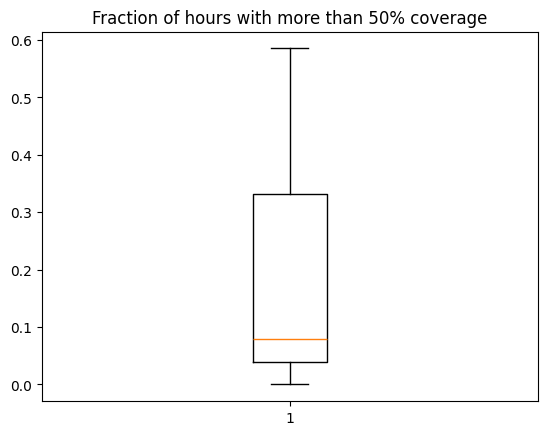

In [ ]:
input_folder = output_folder # The folder that contains all the site subfolders with the cleaned data and metadata features
csv_name = "active_apple_healthkit_heart_rate_h_metadata"
files_list = helper_funcs.get_file_paths(
    input_folder, csv_name, Folder_structure=2, site_list=site_list
)
filter_field = "Coverage (secs) from clean datapoints"  # This can be changed if you want coverage from all datapoints

all_participants = []
for path in files_list:
    df = pd.read_csv(path)
    all_participants.append(
        1 - (len(df[df[filter_field] > 1800]) / len(df[filter_field]))
    )

# Add labels and title
plt.boxplot(all_participants)
plt.title("Fraction of hours with more than 50% coverage")
plt.show()